<img src='https://github.com/destination-earth/DestinE-DataLake-Lab/blob/main/img/DestinE-banner.jpg?raw=true' align='right' width='100%'/>

<font color="#138D75">**EUMETSAT DestinE User Engagement Service**</font> <br>
**Copyright:** 2026 European Union <br>
**License:** MIT <br>
**Authors:** EUMETSAT DestinE User Engagement Service: Ben Loveday (EUMETSAT/Innoflair UG), Joana Brito (EUMETSAT/Innoflair UG), Madalina Ungur (EUMETSAT/Solenix)

<div class="alert alert-block alert-success">
    <h2>EUMETSAT Conference 2026</h2>
    <p><font color="white"><em>From Data to Insights: working with DestinE Data Lake services</em></font></p>
</div>

<div class="alert alert-block alert-warning">
<b> Prerequisites: </b><ul>
   <li>To search and access DEDL data a <a href="https://platform.destine.eu/"> DestinE user account</a> is needed</li></ul>
<b> References: </b><ul>
    <li><a href="https://destine-data-lake-docs.data.destination-earth.eu/en/latest/dedl-discovery-and-data-access/Use-of-Harmonized-Data-Access/Use-of-Harmonized-Data-Access.html">DestinE Data Lake (DEDL) Harmonized Data Access (HDA) documentation</a> </li></ul>
</div>

# Harmonised data access to federated Earth Observation data

<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/DestinE-DataLake-Lab/HDA/EUM_data/DEDL-HDA-FEDERATED-EO.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>

### Data Used

| Dataset | HDA collection ID | HDA collection<br>description |
|:--------------------:|:-----------------------:|:-------------:|
| Cloud Mask - MTG - 0 degree | EO.EUM.DAT.MTG.FCI-CLM | <a href="https://data.destination-earth.eu/data-portfolio/EO.EUM.DAT.MTG.FCI-CLM" target="_blank">Description</a> |
| OLCI Level 2 Ocean Colour Full Resolution - Sentinel-3 | EO.EUM.DAT.SENTINEL-3.OL_2_WFR___ | <a href="https://data.destination-earth.eu/data-portfolio/EO.EUM.DAT.SENTINEL-3.OL_2_WFR___" target="_blank">Description</a> |
| Sentinel 2 MSI Level 1C | EO.ESA.DAT.SENTINEL-2.MSI.L1C | <a href="https://data.destination-earth.eu/data-portfolio/EO.ESA.DAT.SENTINEL-2.MSI.L1C" target="_blank">Description</a> |

### Learning outcomes

After running this notebook, you will be able to:

* Set up and authenticate access to DEDL Harmonised Data Access.
* Discover collections using the STAC implementation.
* Use simple STAC filters to identify collections of interest.
* Search within collections using spatial, temporal and result-limit constraints.
* Inspect STAC Items and their spatial coverage.
* Handle products where a STAC geometry is not supplied.
* Download a complete product and individual product assets.

### Outline

This notebook introduces the **Harmonised Data Access (HDA)** service of the DestinE Data Lake through a simple REST/STAC workflow. We will use three Earth observation collections as examples: MTG FCI Cloud Mask, Sentinel-3 OLCI Level-2 Ocean Colour, and Sentinel-2 MSI Level-1C.

The workflow demonstrates how HDA can be used to move from **data discovery to data access**. We first explore the collections available through the STAC catalogue, then search for products using spatial and temporal constraints, inspect the resulting STAC Items and their geographic coverage, and finally access both complete products and individual product components.

The notebook therefore follows a typical HDA discovery and access workflow:

1. Import the required Python dependencies.
2. Authenticate with HDA and configure the REST/STAC endpoints.
3. Discover and inspect available STAC collections.
4. Search collections for products matching spatial, temporal and other constraints.
5. Inspect and visualise the spatial coverage of the search results.
6. Access and download a complete product or individual product assets.

<div class="alert alert-info" role="alert">

## Importing dependencies

</div>

We begin by importing the libraries used throughout the notebook. The **Python DEDL environment** provides the main dependencies used here.

The workflow deliberately uses standard Python HTTP requests and STAC responses rather than a higher-level data-access library. This makes the underlying HDA interaction visible and helps illustrate what is happening when a client searches for and retrieves DestinE data.


Satpy and pyresample are used below to read the MTG FCI product and resample it onto a regular latitude/longitude grid. These are not included in the standard environment, so we need to add them.

In [1]:
import sys

!{sys.executable} -m pip -q install --user satpy pyresample

In [2]:
import destinelab as deauth                     # DestinE Data Lake authentication and access
from getpass import getpass                     # Securely prompt for passwords
import requests                                 # Make HTTP requests to web services and APIs
import json                                     # Read and write JSON data
import os                                       # Interact with the operating system
import numpy as np                              # Work with numerical arrays
import geopandas                                # Work with geospatial vector data
from IPython.display import JSON                # Display JSON data in Jupyter notebooks
import folium                                   # Create interactive maps
import shapely.geometry                         # Create and manipulate geometric objects
from pathlib import Path                        # Construct and manage system file paths
import math                                     # Mathematical functions and calculations
import zipfile                                  # Extract files from ZIP archives
from satpy import Scene                         # Read and process satellite data
from pyresample.geometry import AreaDefinition  # Define target areas for resampling
import warnings                                 # Control warning messages
warnings.filterwarnings('ignore')

<div class="alert alert-info" role="alert">

## Authenticating the HDA

</div>

HDA requires authentication for data access. For this training notebook we store the credentials locally in a file under the user's home directory so that they do not need to be entered every time the notebook is run.

If the credentials file does not yet exist, the notebook prompts for the DESP username and passwords and creates it. The password prompts use `getpass`, so the credentials are not displayed in the notebook.

**Security note:** this file contains sensitive credentials and should never be committed to a source-control repository or shared with other users.

In [3]:
credentials_file = Path(Path.home() / '.dedl' / 'credentials')

if os.path.exists(credentials_file):
    with open(credentials_file, "r") as f:
        config = json.load(f)
    DESP_USERNAME = config["username"]
    DESP_PASSWORD = config["desp_password"]
else:
    # creating authentication file
    DESP_USERNAME = input("Please input your DESP username or email: ")
    DESP_PASSWORD = getpass("Please input your DESP password: ")
    OIDC_PASSWORD = getpass("Please input your OIDC password (if known): ")

    config = {"username": DESP_USERNAME,
              "desp_password": DESP_PASSWORD,
              "oidc_password": OIDC_PASSWORD}
    try:
        os.makedirs(os.path.dirname(credentials_file), exist_ok=True)        
        with open(credentials_file, "w") as f:
            json.dump(config, f, indent=4)
    except:
        pass

The credentials themselves are not sent directly with every HDA request. Instead, they are exchanged for an **access token** using the DestinE authentication service.

The token is then placed in an HTTP `Authorization` header. This header is reused for the authenticated HDA requests that follow.

In [4]:
auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()

if access_token is not None:
    print("DEDL/DESP Access Token Obtained Successfully")
else:
    print("Failed to Obtain DEDL/DESP Access Token")

auth_headers = {"Authorization": f"Bearer {access_token}"}

DEDL/DESP Access Token Obtained Successfully


<div class="alert alert-info" role="alert">

## Setting HDA endpoints

</div>

HDA exposes a REST API whose catalogue and discovery interfaces follow the **SpatioTemporal Asset Catalog (STAC)** specification.

We therefore define the HDA and STAC base URLs once and build the individual endpoint URLs from them. This keeps the remainder of the notebook readable and makes it clear which part of the URL corresponds to the HDA service and which part corresponds to the STAC API.


In [5]:
HDA_API_URL = "https://hda.data.destination-earth.eu"
STAC_API_URL = f"{HDA_API_URL}/stac/v2"

We now define the main STAC endpoints used in this notebook.

`/collections` is used to discover datasets, `/search` can be used for STAC searches, and the collection-specific item endpoint is used later to retrieve products belonging to a particular collection. The `/download` endpoint is retained here as part of the HDA API configuration, although the examples below use the asset links supplied directly by the STAC Items.


In [6]:
SEARCH_URL = f"{STAC_API_URL}/search"
DOWNLOAD_URL = f"{STAC_API_URL}/download"
COLLECTIONS_URL = f"{STAC_API_URL}/collections"

<div class="alert alert-info" role="alert">

## Searching for collections

</div>

Before searching for individual products, it is useful to understand the **collection level** of the STAC catalogue. A collection describes a dataset or product family and provides metadata about what it contains.

We start by retrieving the available collections. The response is large because each collection can contain substantial descriptive metadata, including spatial and temporal extents, variables and provider information.


In [7]:
response = requests.get(COLLECTIONS_URL,)
JSON(response.json(), expanded=False)

<IPython.core.display.JSON object>

The complete collection catalogue can be very large, so STAC provides filtering mechanisms to narrow the results.

Here we use the **STAC Filter Extension with CQL2**. The expression checks the `federation:backends` property and keeps collections associated with the EUMETSAT backend.

This is useful when the same HDA interface federates data from multiple providers and we want to identify collections belonging to a particular data provider.


In [8]:
response = requests.get(COLLECTIONS_URL,params = {"filter": "A_CONTAINS(federation:backends,'eumetsat')"},)
JSON(response.json(), expanded=False)

<IPython.core.display.JSON object>

We can also use the STAC **Query Extension** through the `q` parameter. This provides a simpler text-based way of finding collections whose metadata match particular terms.

In this example we search for collections containing both **FCI** and **Optimal cloud**. The important distinction is that `q` provides a simple query interface, whereas the `filter` parameter used above supports the more expressive CQL2 filtering model.


In [9]:
response = requests.get(COLLECTIONS_URL,params = {"q": '"FCI" and "Cloud mask"'})
JSON(response.json(), expanded=False)

<IPython.core.display.JSON object>

The same approach can be used to discover the Sentinel-3 OLCI collection. Here the query terms identify the **total suspended matter** product and its **full-resolution** processing level.

At this stage we are still working at collection level: we are identifying *which dataset* contains the information we want, rather than retrieving an individual observation.


In [10]:
response = requests.get(COLLECTIONS_URL,params = {"q":'"total suspended matter" and "Full resolution"'})
JSON(response.json(), expanded=False)

<IPython.core.display.JSON object>

Finally, we repeat the collection discovery step for Sentinel-2 MSI Level-1C data.

The three searches now give us examples from different parts of the Earth observation data portfolio. We can use the same subsequent HDA workflow for all three because they are exposed through the common STAC interface.


In [11]:
response = requests.get(COLLECTIONS_URL,params = {"q":'"Sentinel 2 MSI Level 1C"'})
JSON(response.json(), expanded=False)

<IPython.core.display.JSON object>

<div class="alert alert-info" role="alert">

## Searching for products

</div>

We now move from **collection discovery** to **product discovery**. The collection IDs identified above are stored in a list so that the same search procedure can be applied to each collection.

A useful STAC mental model is:

**Collection → Item → Asset**

A collection describes a product family; an Item represents one specific product/acquisition; and its Assets are the individual data files or components associated with that product.


In [12]:
COLLECTION_IDS = ["EO.EUM.DAT.MTG.FCI-CLM",
                  "EO.EUM.DAT.SENTINEL-3.OL_2_WFR___",
                  "EO.ESA.DAT.SENTINEL-2.MSI.L1C"]

STAC searches can combine several types of constraint. We will use three simple filters in this notebook:

* **Time** — select products within a specified period.
* **Space** — select products intersecting a geographic bounding box.
* **Limit and sorting** — control how many results are returned and their order.

Keeping these filters explicit makes it easier to see how a broad collection is narrowed down to a small set of products suitable for analysis.


In [13]:
start_date = "2026-09-16T09:00:00Z"
end_date = "2026-09-16T11:00:00Z"

We can now add a spatial constraint using a bounding box. STAC represents a bounding box as **west, south, east, north**.

The Python list is converted to a comma-separated string because this notebook is using the REST API through URL query parameters.


In [14]:
bbox = [12.5, 42.6, 14.5, 44.6]
bbox_str = ",".join(map(str, bbox))

Finally, we limit the number of products returned by each search. A small limit is useful during exploration because it keeps the response manageable and avoids downloading or processing unnecessary metadata.

For a production workflow, the limit can be increased or pagination can be used when all matching products are required.


In [15]:
limit = 3

The temporal range, spatial bounding box and result limit define the common search parameters used for all three collections.

The `/search` endpoint uses these parameters together with the collection identifier to find matching STAC Items.

In [16]:
params = {
    "datetime": f"{start_date}/{end_date}",
    "bbox": [float(value) for value in bbox_str.split(",")],
    "limit": limit,
}

Sentinel-2 can be further constrained using its MGRS tile. The `grid:code` property is exposed as a queryable for this collection.

The query is passed as structured JSON to the STAC `/search` endpoint.

In [17]:
utm_tile = "33TUJ"

s2_query = {
    "grid:code": {
        "eq": f"MGRS-{utm_tile}"
    }
}

We can now search each collection using the same common parameters. For Sentinel-2, the MGRS tile query is added to the request.

Because the HDA search endpoint can return results even when the requested `grid:code` has no matches, we validate the returned Sentinel-2 Items locally. Any returned Items from other MGRS tiles are removed, and a search with no matching tile stops the workflow rather than silently using the wrong products.

The validated search results are retained so that we can inspect and visualise the results in the next steps.


In [18]:
search_results = []

for collection_id in COLLECTION_IDS:
    search_params = params | {"collections": [collection_id]}

    if "SENTINEL-2" in collection_id:
        search_params |= {"query": s2_query}

    response = requests.post(
        SEARCH_URL,
        headers={**auth_headers, "Content-Type": "application/json"},
        json=search_params,
    )
    response.raise_for_status()
    result = response.json()
    print(response.request.url)
    print(response.request.body)
    
    search_results.append(result)
    JSON(result)

https://hda.data.destination-earth.eu/stac/v2/search
b'{"datetime": "2026-09-16T09:00:00Z/2026-09-16T11:00:00Z", "bbox": [12.5, 42.6, 14.5, 44.6], "limit": 3, "collections": ["EO.EUM.DAT.MTG.FCI-CLM"]}'
https://hda.data.destination-earth.eu/stac/v2/search
b'{"datetime": "2026-09-16T09:00:00Z/2026-09-16T11:00:00Z", "bbox": [12.5, 42.6, 14.5, 44.6], "limit": 3, "collections": ["EO.EUM.DAT.SENTINEL-3.OL_2_WFR___"]}'
https://hda.data.destination-earth.eu/stac/v2/search
b'{"datetime": "2026-09-16T09:00:00Z/2026-09-16T11:00:00Z", "bbox": [12.5, 42.6, 14.5, 44.6], "limit": 3, "collections": ["EO.ESA.DAT.SENTINEL-2.MSI.L1C"], "query": {"grid:code": {"eq": "MGRS-33TUJ"}}}'


For Sentinel-2, we need to verify the returned items against the requested MGRS tile, and prune the results. The check prevents an unfiltered Sentinel-2 response from being used in the rest of the workflow.

In [19]:
s2_result = search_results[COLLECTION_IDS.index("EO.ESA.DAT.SENTINEL-2.MSI.L1C")]
requested_tile = f"MGRS-{utm_tile}"

s2_result["features"] = [
    feature for feature in s2_result.get("features", [])
    if feature.get("properties", {}).get("grid:code") == requested_tile
]

if s2_result["features"]:
    print(f"Sentinel-2: {len(s2_result['features'])} product(s) found for {requested_tile}.")
else:
    print(f"No Sentinel-2 granules found for {requested_tile}.")

Sentinel-2: 2 product(s) found for MGRS-33TUJ.


The search responses contain **STAC Items** represented as GeoJSON Features. Each Item includes metadata such as its identifier, acquisition time, collection membership, geometry and available assets.

The Sentinel-2 results have been checked against the requested MGRS tile, so the `search_results` object contains only products that match the requested tile.

Converting the features to a GeoDataFrame gives us a convenient way to inspect the results using familiar Python geospatial tools. It also allows the STAC geometry to be displayed directly on an interactive map.


In [20]:
for collection_id, result in zip(COLLECTION_IDS, search_results):

    if result.get("features"):
        df = geopandas.GeoDataFrame.from_features(
            result["features"],
            crs="EPSG:4326"
        )
        display(df.head())
    else:
        print("No products found.")

,geometry,datetime,end_datetime,instruments,platform,size,start_datetime,title,uid,updated,eumetsat:links,order:status,product:type,federation:backends,providers
0,POINT (0 0),2026-09-16T08:50:00Z,2026-09-16T09:00:00Z,[FCI],MTI1,5400,2026-09-16T08:50:00Z,W_XX-EUMETSAT-Darmstadt_IMG_SAT_MTI1_FCI-2-CLM...,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-CLM...",2026-09-16T09:09:32.486Z,"{'type': 'Links', 'data': [{'type': 'Link', 'h...",succeeded,MTIFCI2CLM,[eumetsat],"[{'name': 'eumetsat', 'roles': ['host']}]"
1,POINT (0 0),2026-09-16T09:00:00Z,2026-09-16T09:10:00Z,[FCI],MTI1,5361,2026-09-16T09:00:00Z,W_XX-EUMETSAT-Darmstadt_IMG_SAT_MTI1_FCI-2-CLM...,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-CLM...",2026-09-16T09:20:24.355Z,"{'type': 'Links', 'data': [{'type': 'Link', 'h...",succeeded,MTIFCI2CLM,[eumetsat],"[{'name': 'eumetsat', 'roles': ['host']}]"
2,POINT (0 0),2026-09-16T09:10:00Z,2026-09-16T09:20:00Z,[FCI],MTI1,5314,2026-09-16T09:10:00Z,W_XX-EUMETSAT-Darmstadt_IMG_SAT_MTI1_FCI-2-CLM...,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-CLM...",2026-09-16T09:29:45.7Z,"{'type': 'Links', 'data': [{'type': 'Link', 'h...",succeeded,MTIFCI2CLM,[eumetsat],"[{'name': 'eumetsat', 'roles': ['host']}]"


,geometry,datetime,end_datetime,instruments,platform,size,start_datetime,title,uid,updated,eumetsat:links,order:status,product:timeliness,product:type,sat:absolute_orbit,sat:orbit_cycle,sat:orbit_state,sat:relative_orbit,federation:backends,providers
0,"POLYGON ((7.36943 41.9647, 8.1958 41.8897, 9.0...",2026-09-16T09:12:15.326896Z,2026-09-16T09:15:15.326896Z,[OLCI],Sentinel-3B,197763,2026-09-16T09:12:15.326896Z,S3B_OL_2_WFR____20260916T091215_20260916T09151...,S3B_OL_2_WFR____20260916T091215_20260916T09151...,2026-09-16T11:15:57.507Z,"{'type': 'Links', 'data': [{'type': 'Link', 'h...",succeeded,NR,OL_2_WFR___,43713,124,descending,321,[eumetsat],"[{'name': 'eumetsat', 'roles': ['host']}]"
1,"POLYGON ((7.36943 41.9647, 8.1958 41.8897, 9.0...",2026-09-16T09:12:15.326631Z,2026-09-16T09:15:15.326631Z,[OLCI],Sentinel-3B,222375,2026-09-16T09:12:15.326631Z,S3B_OL_2_WFR____20260916T091215_20260916T09151...,S3B_OL_2_WFR____20260916T091215_20260916T09151...,2026-09-17T13:33:46.052Z,"{'type': 'Links', 'data': [{'type': 'Link', 'h...",succeeded,NT,OL_2_WFR___,43713,124,descending,321,[eumetsat],"[{'name': 'eumetsat', 'roles': ['host']}]"
2,"POLYGON ((-2.45153 41.9742, -1.61306 41.8966, ...",2026-09-16T09:50:56.783853Z,2026-09-16T09:53:56.783853Z,[OLCI],Sentinel-3A,287430,2026-09-16T09:50:56.783853Z,S3A_OL_2_WFR____20260916T095057_20260916T09535...,S3A_OL_2_WFR____20260916T095057_20260916T09535...,2026-09-17T15:02:20.585Z,"{'type': 'Links', 'data': [{'type': 'Link', 'h...",succeeded,NT,OL_2_WFR___,55107,144,descending,79,[eumetsat],"[{'name': 'eumetsat', 'roles': ['host']}]"


,geometry,constellation,datetime,end_datetime,instruments,platform,providers,published,start_datetime,title,...,processing:level,processing:version,product:type,s2:datastrip_id,s2:datatake_id,s2:datatake_type,s2:tile_id,sat:absolute_orbit,sat:relative_orbit,federation:backends
0,"POLYGON ((12.49593 44.22596, 12.53677 43.23826...",SENTINEL-2,2026-09-16T10:00:29.024000Z,2026-09-16T10:00:29.024000Z,[MSI],S2B,"[{'name': 'ESA', 'roles': ['producer']}, {'nam...",2026-09-16T14:42:57.495857Z,2026-09-16T10:00:29.024000Z,S2B_MSIL1C_20260916T100029_N0512_R122_T33TUJ_2...,...,S2MSI1C,5.12,S2MSI1C,S2B_OPER_MSI_L1C_DS_2BPS_20260916T140917_S2026...,GS2B_20260916T100029_049769_N05.12,INS-NOBS,S2B_OPER_MSI_L1C_TL_2BPS_20260916T140917_A0497...,49769,122,[external_fdp]
1,"POLYGON ((13.17235 44.23673, 12.49593 44.22596...",SENTINEL-2,2026-09-16T10:07:01.024000Z,2026-09-16T10:07:01.024000Z,[MSI],S2A,"[{'name': 'ESA', 'roles': ['producer']}, {'nam...",2026-09-16T16:54:09.627407Z,2026-09-16T10:07:01.024000Z,S2A_MSIL1C_20260916T100701_N0512_R022_T33TUJ_2...,...,S2MSI1C,5.12,S2MSI1C,S2A_OPER_MSI_L1C_DS_2APS_20260916T152630_S2026...,GS2A_20260916T100701_058678_N05.12,INS-NOBS,S2A_OPER_MSI_L1C_TL_2APS_20260916T152630_A0586...,58678,22,[external_fdp]


<div class="alert alert-info" role="alert">

## Visualising results

</div>

The next step is to visualise the spatial coverage returned by the search. This is a useful validation step: before downloading data, we can check whether the products actually cover the area we are interested in.

The map uses Folium so that the search results can be explored interactively in the notebook.


In [21]:
map1 = folium.Map([38, 0],zoom_start=4, tiles=None)

nasa_wms = folium.WmsTileLayer(
    url='https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi',
    name='NASA Blue Marble',
    layers='BlueMarble_ShadedRelief',
    format='image/png',
    transparent=True,
    attr='NASA'
)
nasa_wms.add_to(map1);

We also display the **search bounding box** on the map. This makes it possible to compare the geographic area requested by the user with the actual spatial coverage reported by the STAC Items.


In [22]:
bb=folium.GeoJson(
    shapely.geometry.box(*bbox),name='Search bounding box',style_function=lambda feature: {
        "fillColor": "#ff0000",
        "color": "black",
        "weight": 2,
        "dashArray": "5, 5",
    }
)
bb.add_to(map1);

The STAC search results can now be added to the map. Each returned Item is displayed using the geometry supplied by the STAC response.

For the MTG FCI product, the STAC geometry is a point at (0, 0), rather than a representative footprint. We will leave that point in place, and add a locally generated approximate MTG coverage polygon for visualisation.


In [23]:
for result in search_results:
    results = folium.GeoJson(
        result,
        name='Search results',
        style_function=lambda feature: {
            'color': 'black',
            'weight': 1,
            'fillOpacity': 0.1
        }
    )
    results.add_to(map1)

For the MTG FCI product, we can supplement the STAC point with a locally generated approximate footprint. The MTG FCI instrument is geostationary, so its full-disk coverage has a curved boundary when represented in geographic (longitude/latitude) coordinates. 

**Note: The polygon below approximates this visible Earth disk for visualisation only; it does not modify the STAC metadata.**

In [24]:
# Approximate geographic footprint for the MTG FCI full-disk product
k = 6378 / (6378 + 35786)
m = math.degrees(math.acos(k))

lons = [-m + 2*m*i/120 for i in range(121)]
coords = [(x, math.degrees(math.acos(k / math.cos(math.radians(x))))) for x in lons[1:-1]]
footprint = shapely.geometry.Polygon(coords + [(x, -y) for x, y in coords[::-1]])

folium.GeoJson(footprint, name="MTG FCI approximate coverage",).add_to(map1);

Lets now plot the map!

In [25]:
map1

The map now shows the STAC search results, including the MTG point at (0, 0), together with a locally generated approximate MTG full-disk coverage polygon.

Because the map uses geographic coordinates, the MTG footprint appears as a curved shape rather than a simple rectangle. The polygon is a visual aid only: it is not part of the STAC Item and does not alter the HDA metadata.

<div class="alert alert-info" role="alert">

## Download results

</div>

The STAC search has now taken us from **dataset discovery to specific products**. The final step is to access the actual data.

A STAC Item can contain one or more **Assets**. An Asset represents a downloadable file or component of the product and provides its own `href`. HDA therefore supports both complete-product downloads and asset-level access.

### Example 1: Download and upzip a complete product

The `downloadLink` asset provides access to the complete product as a downloadable archive. Here we download the first MTG product returned by the search.

In [26]:
mtg_product = search_results[0]['features'][0]
item_id = mtg_product['id']
download_url = mtg_product['assets']['downloadLink']['href']
output_path = Path('hda_downloads') / item_id / f'{item_id}.zip'
extract_path = output_path.parent / item_id
output_path.parent.mkdir(parents=True, exist_ok=True)

print(f'Product: {item_id}')
print(f'Downloading -> {output_path}')

with requests.get(download_url, headers=auth_headers, stream=True) as r:
    r.raise_for_status()
    with open(output_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

print(f'Downloaded: {output_path}')

Product: W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-CLM--FD--x-x---x_C_EUMT_20260916090924_L2PF_OPE_20260916085000_20260916090000_N__O_0054_0000
Downloaded: hda_downloads/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-CLM--FD--x-x---x_C_EUMT_20260916090924_L2PF_OPE_20260916085000_20260916090000_N__O_0054_0000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-CLM--FD--x-x---x_C_EUMT_20260916090924_L2PF_OPE_20260916085000_20260916090000_N__O_0054_0000.zip


Now we can unzip our full product and remove the latent zipfile.

In [27]:
with zipfile.ZipFile(output_path, 'r') as z:
    z.extractall(extract_path)

output_path.unlink()

print(f'Extracted: {extract_path}')

Extracted: hda_downloads/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-CLM--FD--x-x---x_C_EUMT_20260916090924_L2PF_OPE_20260916085000_20260916090000_N__O_0054_0000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-CLM--FD--x-x---x_C_EUMT_20260916090924_L2PF_OPE_20260916085000_20260916090000_N__O_0054_0000


### Example 2: Download an individual asset

In many workflows we do not need every file associated with a product. Instead, we may only need one particular component — for example, a single band, resolution or auxiliary file.

The code below selects the first asset from the first product returned for each collection. Each asset is stored in a folder named after its product, while the path structure from the product onwards is retained.

In [28]:
for collection_id, result in zip(COLLECTION_IDS, search_results):
    features = result.get('features', [])
    if not features:
        print(f'No products found for {collection_id}')
        continue

    item = features[0]
    assets = item.get('assets', {})
    if not assets:
        print(f'No assets found for {collection_id}')
        continue

    asset_key, asset = next(((k, v) for k, v in assets.items() if k != 'downloadLink'), (None, None))
    if asset is None:
        print(f'No individual assets found for {collection_id}')
        continue

    asset_url = asset.get('href')
    if not asset_url:
        print(f'Asset {asset_key} has no download URL for {collection_id}')
        continue

    path_parts = asset_url.split('?')[0].split('/')
    try:
        relative_path = Path(*path_parts[path_parts.index(item['id']):])
    except ValueError:
        relative_path = Path(path_parts[-1] or f'{asset_key}.data')

    output_path = Path('hda_downloads') / item['id'] / relative_path
    output_path.parent.mkdir(parents=True, exist_ok=True)

    print(f'{collection_id}: downloading {asset_key} -> {output_path}')
    with requests.get(asset_url, headers=auth_headers, stream=True) as r:
        r.raise_for_status()
        with open(output_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

    print(f'Downloaded: {output_path}')

EO.EUM.DAT.MTG.FCI-CLM: downloading EOPMetadata.xml -> hda_downloads/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-CLM--FD--x-x---x_C_EUMT_20260916090924_L2PF_OPE_20260916085000_20260916090000_N__O_0054_0000/EOPMetadata.xml
Downloaded: hda_downloads/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-CLM--FD--x-x---x_C_EUMT_20260916090924_L2PF_OPE_20260916085000_20260916090000_N__O_0054_0000/EOPMetadata.xml
EO.EUM.DAT.SENTINEL-3.OL_2_WFR___: downloading EOPMetadata.xml -> hda_downloads/S3B_OL_2_WFR____20260916T091215_20260916T091515_20260916T111208_0179_124_321_2160_MAR_O_NR_004.SEN3/S3B_OL_2_WFR____20260916T091215_20260916T091515_20260916T111208_0179_124_321_2160_MAR_O_NR_004.SEN3/EOPMetadata.xml
Downloaded: hda_downloads/S3B_OL_2_WFR____20260916T091215_20260916T091515_20260916T111208_0179_124_321_2160_MAR_O_NR_004.SEN3/S3B_OL_2_WFR____20260916T091215_20260916T091515_20260916T111208_0179_124_321_2160_MAR_O_NR_004.SEN3/EOPMetadata.xml
EO.ESA.DAT.SENTINEL-2.MSI.L1C: downloading B01 -> hda_downloads

### Choosing a specific component

The example above deliberately selects the first asset returned by each STAC Item. In an application workflow, you would normally inspect the asset keys and select the component explicitly:

```python
asset = item["assets"]["<asset-key>"]
asset_url = asset["href"]
```

This provides a simple pattern for moving from **STAC discovery → product selection → asset selection → authenticated download**.

Quick view of our satpy product

<div class="alert alert-info" role="alert">

## Plotting our data

</div>

We have now downloaded a complete MTG FCI Cloud Mask product. Satpy provides a reader for the FCI Level-2 NetCDF format, so we can load the cloud state directly from the product.

In [29]:
product_path = next(Path('hda_downloads').rglob('W_XX*/*.nc'))
scn = Scene(filenames=[str(product_path)], reader='fci_l2_nc')
scn.load(['cloud_state'])

The FCI product is provided in its native satellite projection. We resample the cloud state onto a regular latitude/longitude grid covering the HDA search area, padded by 5 degrees.

In [30]:
pad = 5

target_area = AreaDefinition(
    'roi', 'ROI', 'roi', {'proj': 'longlat', 'datum': 'WGS84'},
    1000, 1000,
    (bbox[0] - pad, bbox[1] - pad, bbox[2] + pad, bbox[3] + pad)
)

scn_ll = scn.resample(target_area, resampler='nearest')

The resampled cloud state can now be added to the Folium map alongside the product footprints. Cloud state is categorical, so we use a discrete mask: values 1 and 2 are shown in red, while values 0 and 3 are transparent.

The layer is added before the Layer Control so it can be switched on and off together with the other map layers.


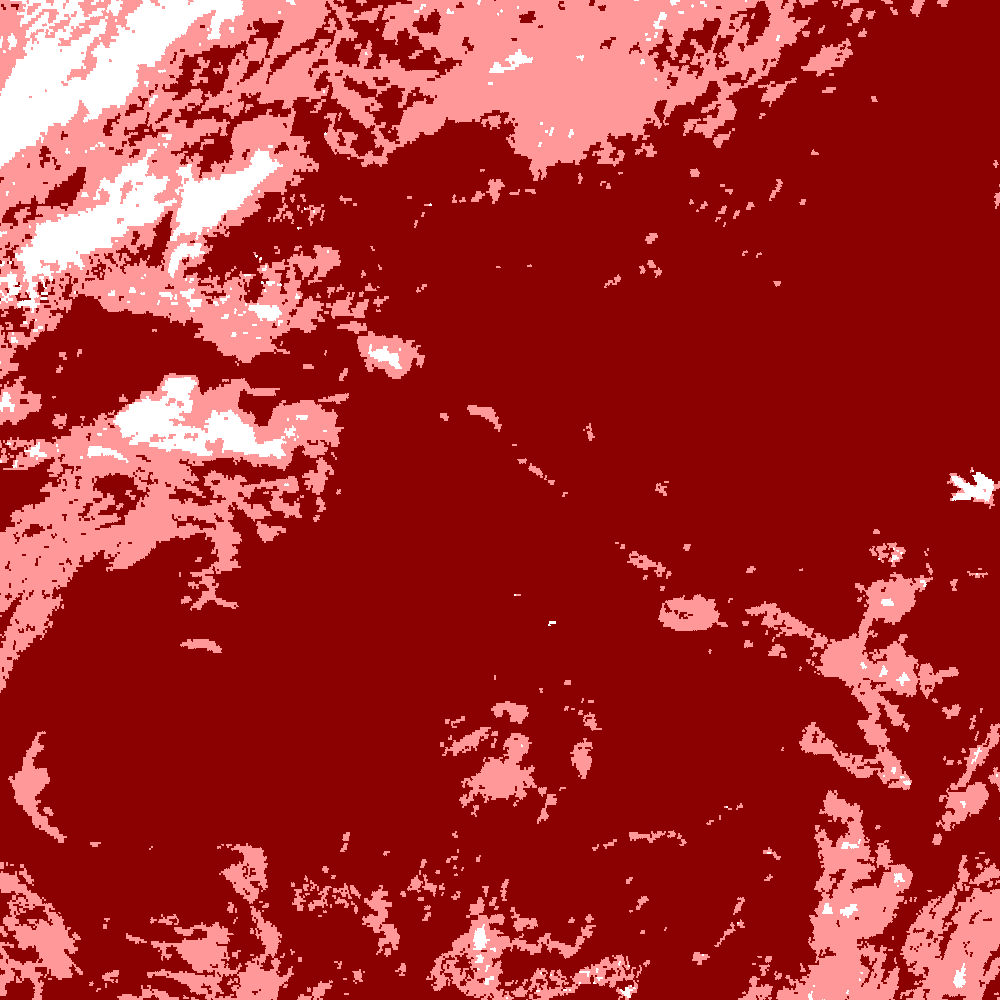

In [31]:
data = scn_ll['cloud_state'].values

# Discrete cloud-state mask: 0/3 transparent, 1 dark red, 2 light red
rgba = np.zeros((*data.shape, 4), dtype=np.uint8)
rgba[data == 1] = [139, 0, 0, 255]
rgba[data == 2] = [255, 153, 153, 255]

west, south, east, north = target_area.area_extent

folium.raster_layers.ImageOverlay(
    image=rgba,
    bounds=[[south, west], [north, east]],
    opacity=1.0,
    origin='upper',
    name='MTG FCI Cloud State'
).add_to(map1)

folium.LayerControl().add_to(map1)

map1

<div class="alert alert-info" role="alert">

## Conclusion

</div>

This notebook has taken us through the complete HDA workflow: **authenticate → discover collections → search for products → inspect STAC Items → visualise coverage → download data**. The same STAC-based approach can be extended to other DestinE Data Lake collections and to more advanced spatial, temporal and attribute-based searches.

For further information, see the following guides:
* <a href="https://destine-data-lake-docs.data.destination-earth.eu/en/latest/dedl-discovery-and-data-access/Harmonized-Data-Access/API-Architecture/API-Architecture.html" target="_blank">HDA API Architecture</a>
* <a href="https://destine-data-lake-docs.data.destination-earth.eu/en/latest/dedl-discovery-and-data-access/Harmonized-Data-Access/API-Guide/Services-and-Data-Discovery.html" target="_blank">HDA Data Discovery guide</a>
* <a href="https://destine-data-lake-docs.data.destination-earth.eu/en/latest/dedl-discovery-and-data-access/Harmonized-Data-Access/API-Guide/Data-Access.html" target="_blank">HDA Data Access guide</a>
* <a href="https://destine-data-lake-docs.data.destination-earth.eu/en/latest/dedl-discovery-and-data-access/Harmonized-Data-Access/Quick-Start/Quick-Start.html" target="_blank">HDA Quick Start guide</a>

<img src='https://github.com/destination-earth/DestinE-DataLake-Lab/blob/main/img/DestinE-banner.jpg?raw=true' align='right' width='100%'/>